# Classification Model Evaluation

Evaluates `OrdinalPairClassifier` on the held-out test split. Covers accuracy, MAE, confusion matrices, error distributions, per-bucket breakdowns, and qualitative examples.

In [1]:
import sys
from pathlib import Path

# Add ChordEdit root so 'models.classification.*' imports work
ROOT = Path.cwd().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import DataLoader

from models.classification.model import (
    OrdinalPairClassifier,
    decode_ordinal,
    mae_buckets,
)
from models.classification.classify import PairDataset, collate, eval_loader

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load Data

In [2]:
from models.classification.settings import OUTPUTS_DIR

run_dirs = sorted(d for d in OUTPUTS_DIR.iterdir() if d.is_dir())
assert run_dirs, f"No run directories found in {OUTPUTS_DIR}"
RUN_DIR = run_dirs[-1]
print(f"Using run: {RUN_DIR.name}")

train_df = pd.read_parquet(RUN_DIR / "train.parquet.gz")
val_df   = pd.read_parquet(RUN_DIR / "val.parquet.gz")
test_df  = pd.read_parquet(RUN_DIR / "test.parquet.gz")

print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")
print(f"t_start buckets: {sorted(train_df['t_start'].unique())}")
print(f"t_end   buckets: {sorted(train_df['t_end'].unique())}")
test_df

Using run: 20260618_120016
train: 448  val: 56  test: 56
t_start buckets: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]
t_end   buckets: [np.float64(0.3)]


,sample_id,t_start,t_end,id,source_prompt,target_prompt,t_start_idx,t_end_idx
0,111000000008,0.4,0.3,111000000008,a [monkey] wearing colorful goggles and a colo...,a [man] wearing colorful goggles and a colorfu...,4,0
1,112000000003,0.4,0.3,112000000003,a girl with black hair and a white shirt is ho...,a girl with black hair and a white shirt is ho...,4,0
2,112000000004,0.4,0.3,112000000004,a cartoon girl sitting on a [backpack],a cartoon girl sitting on a [rock],4,0
3,114000000004,0.1,0.3,114000000004,a blue pyramid with a reflection of [mountains...,a blue pyramid with a reflection of [ship] in ...,1,0
4,121000000003,0.3,0.3,121000000003,a white [bulldog] is walking on the grass,a white [rat] is walking on the grass,3,0
5,123000000002,0.6,0.3,123000000002,a [book] on the table,a [painting] on the table,6,0
6,123000000004,0.0,0.3,123000000004,a blue glass [pendant] on a black cord,a blue glass [purse] on a black cord,0,0
7,211000000007,0.6,0.3,211000000007,a digital art of charcoal grey little squirrel...,a digital art of charcoal grey little squirrel...,6,0
8,213000000002,0.1,0.3,213000000002,paper art,paper art [and kids],1,0
9,213000000005,0.4,0.3,213000000005,a large brown teddy bear sitting on a white couch,a large brown teddy bear [and a girl] sitting ...,4,0


### 2. Load Model

In [ ]:
from models.classification.settings import FREEZE_ENCODER

weights_path = RUN_DIR / "classifier_weights.pt"
assert weights_path.exists(), f"No weights found in {RUN_DIR}"
print(f"Loading: {weights_path}  (run: {RUN_DIR.name})")

ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)
buckets_start = torch.tensor(ckpt["buckets1"], dtype=torch.float)
buckets_end   = torch.tensor(ckpt["buckets2"], dtype=torch.float)
print(f"Checkpoint config: {ckpt['config']}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = OrdinalPairClassifier(
    buckets1=buckets_start, buckets2=buckets_end, freeze_encoder=FREEZE_ENCODER
).to(DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"Device: {DEVICE}")

bucket_vals_start = buckets_start.numpy()
bucket_vals_end   = buckets_end.numpy()
N_BUCKETS_START   = len(bucket_vals_start)
N_BUCKETS_END     = len(bucket_vals_end)
BUCKET_LABELS_START = [f"{v:.3g}" for v in bucket_vals_start]
BUCKET_LABELS_END   = [f"{v:.3g}" for v in bucket_vals_end]
print(f"t_start: {N_BUCKETS_START} buckets {BUCKET_LABELS_START}")
print(f"t_end:   {N_BUCKETS_END} buckets {BUCKET_LABELS_END}")

Loading: /data/home/mirick/ChordEdit/models/classification/outputs/sdturbo/20260618_120016/classifier_weights.pt  (run: 20260618_120016)
Checkpoint config: {'run_dir': '/data/home/mirick/ChordEdit/models/classification/outputs/sdturbo/20260618_120016', 'PARENT_DIR': '/data/home/mirick/ChordEdit/models/classification', 'DATA_DIR': '/data/home/mirick/ChordEdit/models/classification/data', 'METRICS_CSV': '/data/home/mirick/ChordEdit/models/classification/data/id_to_metrics_sdturbo.csv', 'STRINGS_CSV': '/data/home/mirick/ChordEdit/models/classification/data/id_to_string_pair.csv', 'OUTPUTS_DIR': '/data/home/mirick/ChordEdit/models/classification/outputs/sdturbo', 'N_BUCKETS_START': 11, 'N_BUCKETS_END': 1, 'COMPUTED_METRIC_FN': 'compute_combined_score', 'COMPUTED_METRIC_COL': 'combined_score', 'COMPUTED_METRIC_LABEL': 'Combined Score', 'TARGET_COLUMN': 'combined_score', 'DELTA_VALUE': 0.0, 'ENCODER_MODEL': 'sentence-transformers/all-MiniLM-L6-v2', 'FREEZE_ENCODER': False, 'SEED': 42, 'EPOCH

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8420.66it/s]


Device: cuda
t_start: 11 buckets ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1']
t_end:   1 buckets ['0.3']


### 3. Run Inference on All Splits

In [4]:
from models.classification.settings import BATCH_SIZE

def predict_split(df: pd.DataFrame) -> dict:
    """Return dict with pred/true arrays for both heads."""
    loader = DataLoader(PairDataset(df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    p1_list, p2_list, l1_list, l2_list = [], [], [], []
    with torch.no_grad():
        for srcs, tgts, l1, l2 in loader:
            l1, l2 = l1.to(DEVICE), l2.to(DEVICE)
            out1, out2 = model(srcs, tgts)
            p1_list.append(decode_ordinal(out1).cpu())
            p2_list.append(decode_ordinal(out2).cpu())
            l1_list.append(l1.cpu())
            l2_list.append(l2.cpu())
    return {
        "pred_start": torch.cat(p1_list).numpy(),
        "pred_end":   torch.cat(p2_list).numpy(),
        "true_start": torch.cat(l1_list).numpy(),
        "true_end":   torch.cat(l2_list).numpy(),
    }

results = {
    "train": predict_split(train_df),
    "val":   predict_split(val_df),
    "test":  predict_split(test_df),
}
print("Inference complete.")

Inference complete.


### 4. Metrics Summary

In [5]:
def compute_metrics(r: dict) -> dict:
    p1 = torch.tensor(r["pred_start"])
    p2 = torch.tensor(r["pred_end"])
    t1 = torch.tensor(r["true_start"])
    t2 = torch.tensor(r["true_end"])
    return {
        "mae_start":  mae_buckets(p1, t1).item(),
        "mae_end":    mae_buckets(p2, t2).item(),
        "acc_start":  (p1 == t1).float().mean().item(),
        "acc_end":    (p2 == t2).float().mean().item(),
        "acc_both":   ((p1 == t1) & (p2 == t2)).float().mean().item(),
    }

metrics_df = pd.DataFrame(
    {split: compute_metrics(r) for split, r in results.items()}
).T.rename(columns={
    "mae_start": "MAE t_start",
    "mae_end":   "MAE t_end",
    "acc_start": "Acc t_start",
    "acc_end":   "Acc t_end",
    "acc_both":  "Joint Acc",
})
metrics_df.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=0)

,MAE t_start,MAE t_end,Acc t_start,Acc t_end,Joint Acc
train,2.116,0.000,0.165,1.000,0.165
val,1.893,0.000,0.161,1.000,0.161
test,2.250,0.000,0.107,1.000,0.107


### 5. Metrics Across Splits (Bar Chart)

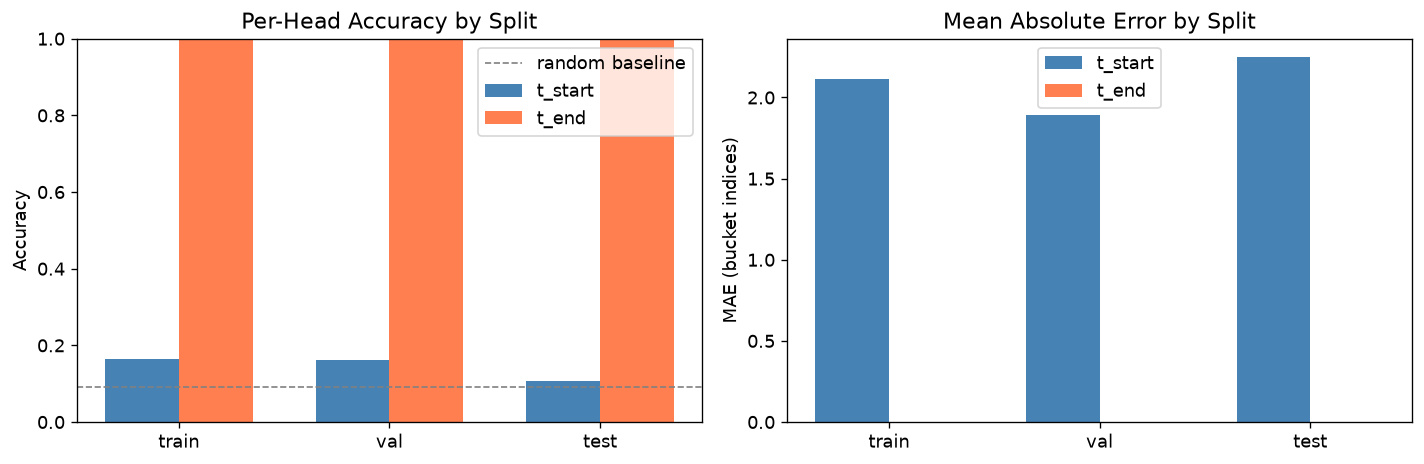

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
splits = ["train", "val", "test"]
x = np.arange(len(splits))
width = 0.35

# Accuracy panel
ax = axes[0]
m = {s: compute_metrics(results[s]) for s in splits}
ax.bar(x - width/2, [m[s]["acc_start"] for s in splits], width, label="t_start", color="steelblue")
ax.bar(x + width/2, [m[s]["acc_end"]   for s in splits], width, label="t_end",   color="coral")
ax.axhline(1/N_BUCKETS_START, color="gray", linestyle="--", linewidth=1, label="random baseline")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("Accuracy"); ax.set_title("Per-Head Accuracy by Split")
ax.set_ylim(0, 1); ax.legend()

# MAE panel
ax = axes[1]
ax.bar(x - width/2, [m[s]["mae_start"] for s in splits], width, label="t_start", color="steelblue")
ax.bar(x + width/2, [m[s]["mae_end"]   for s in splits], width, label="t_end",   color="coral")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("MAE (bucket indices)"); ax.set_title("Mean Absolute Error by Split")
ax.legend()

plt.tight_layout()
plt.savefig("outputs/metrics_by_split.png", bbox_inches="tight")
plt.show()

### 6. Confusion Matrices (Test Set)

/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


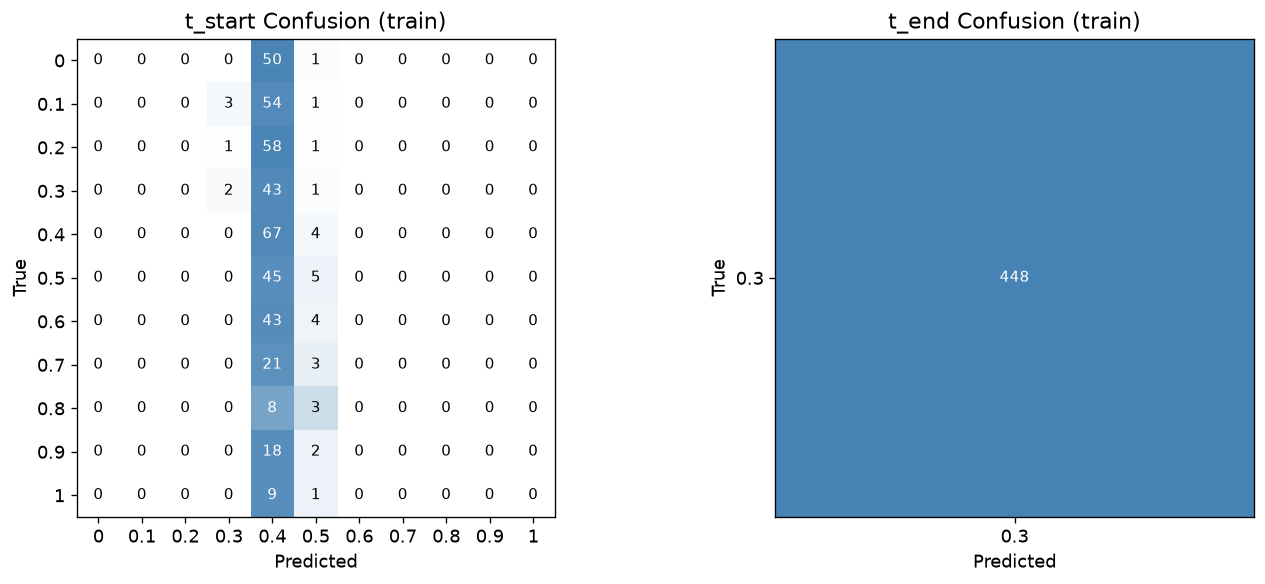

/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


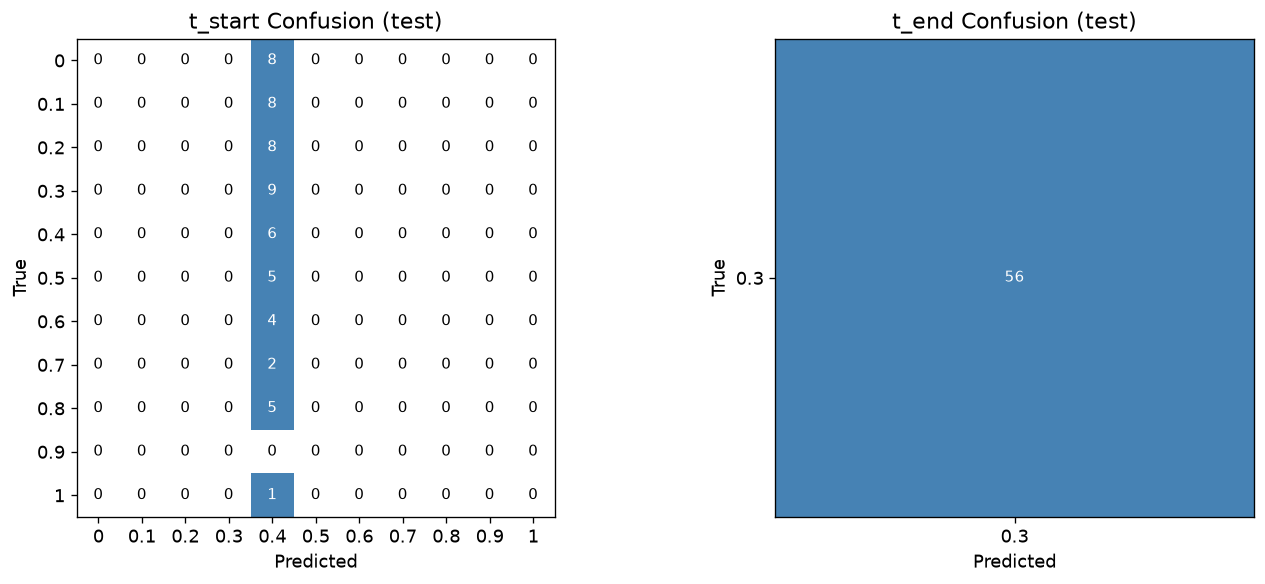

/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/sklearn/metrics/_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


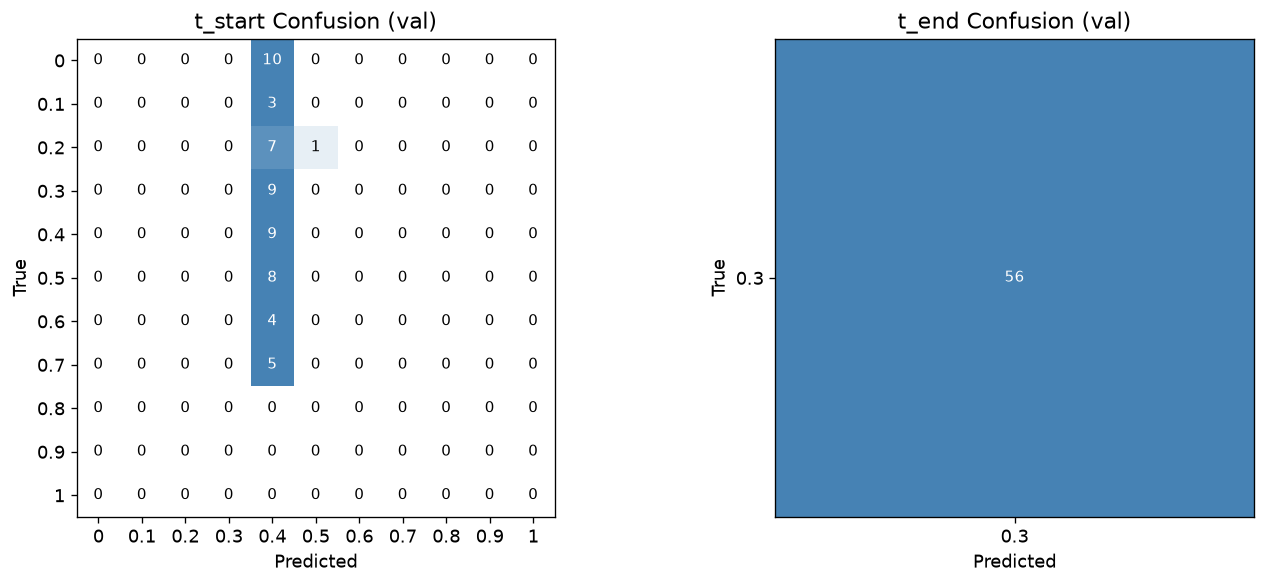

In [7]:
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

cmap = LinearSegmentedColormap.from_list("wb", ["white", "steelblue"])

def plot_confusion(ax, true, pred, title, bucket_labels):
    n_buckets = len(bucket_labels)

    cm = confusion_matrix(true, pred, labels=list(range(n_buckets)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)

    for i in range(n_buckets):
        for j in range(n_buckets):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=9, color="white" if cm_norm[i, j] > 0.5 else "black")

    ax.set_xticks(range(n_buckets))
    ax.set_yticks(range(n_buckets))
    ax.set_xticklabels(bucket_labels)
    ax.set_yticklabels(bucket_labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    return im

def plot_split(split):
    r = results[split]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_confusion(axes[0], r["true_start"], r["pred_start"], f"t_start Confusion ({split})", BUCKET_LABELS_START)
    im = plot_confusion(axes[1], r["true_end"], r["pred_end"], f"t_end Confusion ({split})", BUCKET_LABELS_END)
    plt.tight_layout()

    # unique filename per split
    plt.savefig(f"outputs/confusion_matrices_{split}.png", bbox_inches="tight")

    plt.show()
    plt.close(fig)

for split in ["train", "test", "val"]:
    plot_split(split)

### 7. Error Distribution

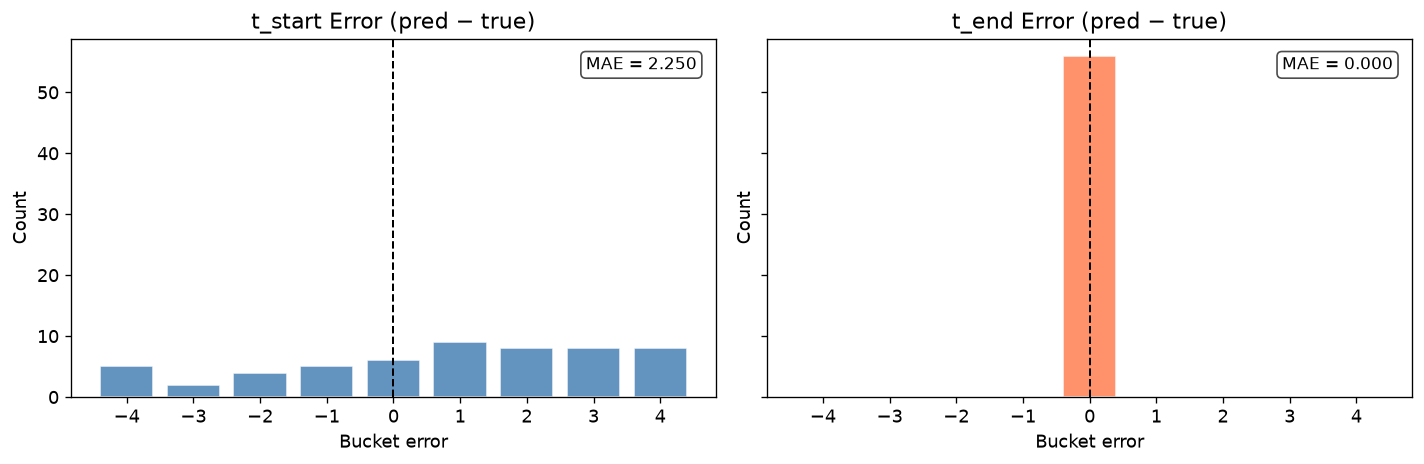

In [8]:
r = results["test"]
err_start = r["pred_start"] - r["true_start"]
err_end   = r["pred_end"]   - r["true_end"]

bins = np.arange(-4.5, 5.5, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, err, title, color in [
    (axes[0], err_start, "t_start Error (pred − true)", "steelblue"),
    (axes[1], err_end,   "t_end Error (pred − true)",   "coral"),
]:
    counts, edges = np.histogram(err, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    ax.bar(centers, counts, width=0.8, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Bucket error")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    mae_val = np.abs(err).mean()
    ax.text(0.97, 0.95, f"MAE = {mae_val:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.savefig("outputs/error_distribution.png", bbox_inches="tight")
plt.show()

### 8. Predicted vs. True Class Distributions

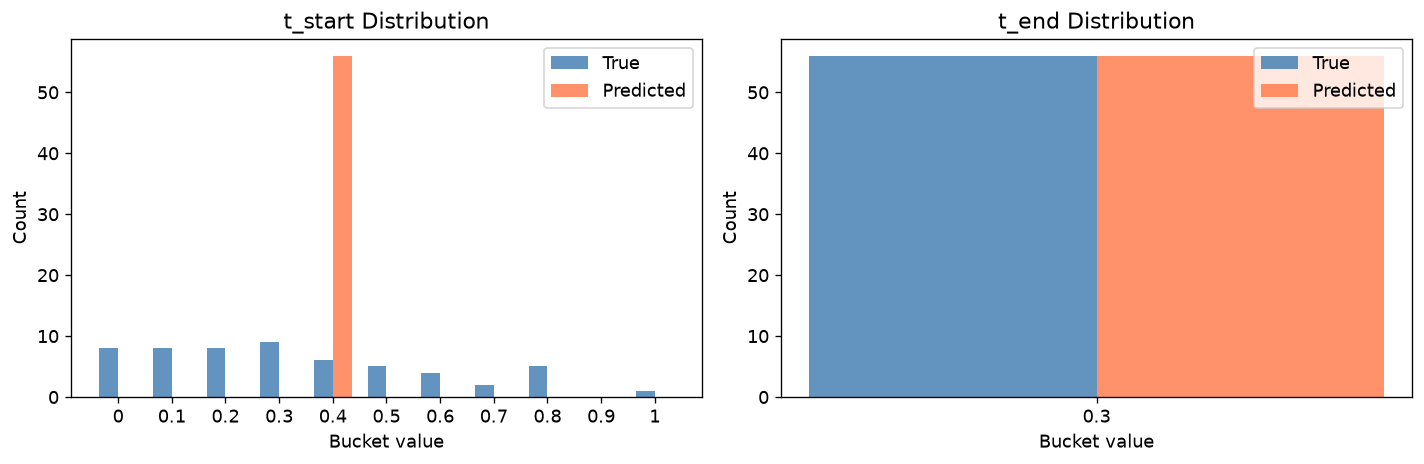

In [9]:
r = results["test"]
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred_key, true_key, title, n_buckets, bucket_labels in [
    (axes[0], "pred_start", "true_start", "t_start Distribution", N_BUCKETS_START, BUCKET_LABELS_START),
    (axes[1], "pred_end",   "true_end",   "t_end Distribution",   N_BUCKETS_END,   BUCKET_LABELS_END),
]:
    x = np.arange(n_buckets)
    true_counts = np.bincount(r[true_key], minlength=n_buckets)
    pred_counts = np.bincount(r[pred_key], minlength=n_buckets)
    ax.bar(x - width/2, true_counts, width, label="True",      color="steelblue", alpha=0.85)
    ax.bar(x + width/2, pred_counts, width, label="Predicted", color="coral",     alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(bucket_labels)
    ax.set_xlabel("Bucket value"); ax.set_ylabel("Count")
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig("outputs/class_distribution.png", bbox_inches="tight")
plt.show()

### 9. Per-Bucket Accuracy

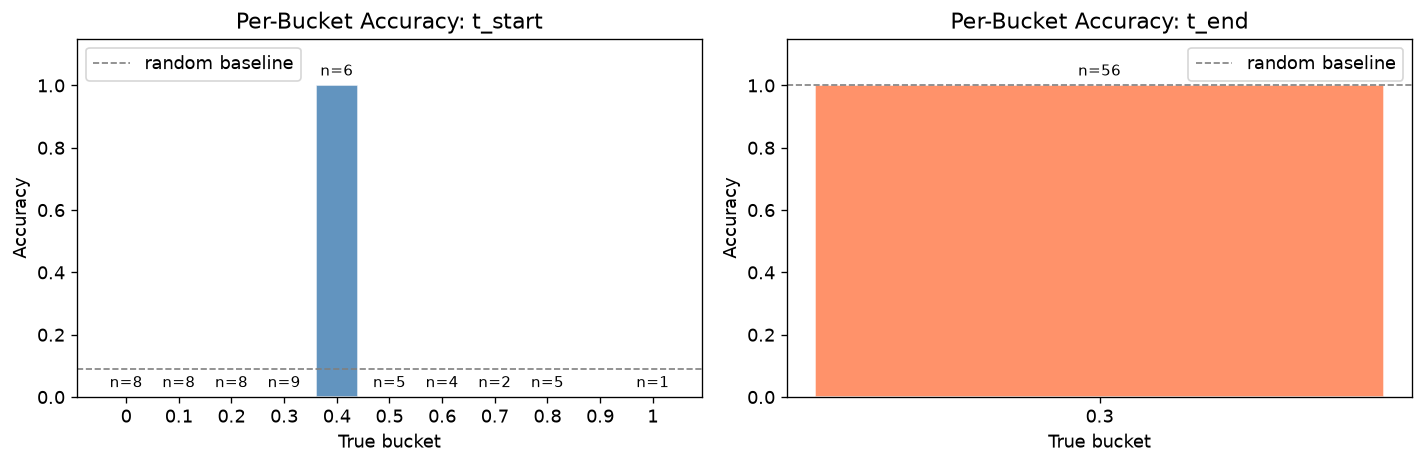

In [10]:
r = results["test"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred_key, true_key, title, color, n_buckets, bucket_labels in [
    (axes[0], "pred_start", "true_start", "Per-Bucket Accuracy: t_start", "steelblue", N_BUCKETS_START, BUCKET_LABELS_START),
    (axes[1], "pred_end",   "true_end",   "Per-Bucket Accuracy: t_end",   "coral",     N_BUCKETS_END,   BUCKET_LABELS_END),
]:
    accs, counts = [], []
    for bucket in range(n_buckets):
        mask = r[true_key] == bucket
        n = mask.sum()
        acc = (r[pred_key][mask] == bucket).mean() if n > 0 else float("nan")
        accs.append(acc)
        counts.append(n)
    bars = ax.bar(range(n_buckets), accs, color=color, alpha=0.85, edgecolor="white")
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"n={n}", ha="center", va="bottom", fontsize=9)
    ax.axhline(1/n_buckets, color="gray", linestyle="--", linewidth=1, label="random baseline")
    ax.set_xticks(range(n_buckets)); ax.set_xticklabels(bucket_labels)
    ax.set_xlabel("True bucket"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.15); ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig("outputs/per_bucket_accuracy.png", bbox_inches="tight")
plt.show()

### 10. Scatter: Predicted vs. True Bucket Indices

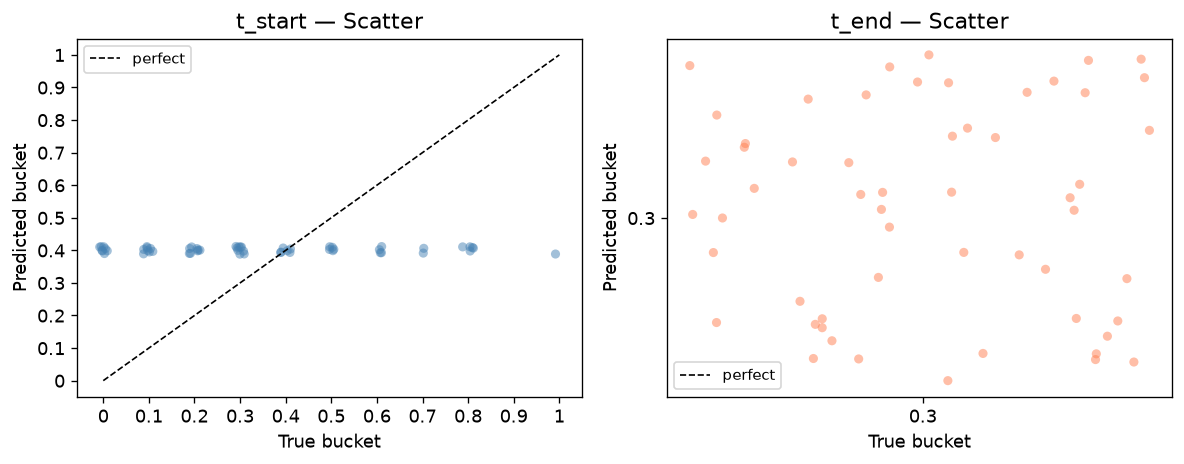

In [11]:
r = results["test"]
jitter = 0.12
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, pred_key, true_key, title, color, n_buckets, bucket_labels in [
    (axes[0], "pred_start", "true_start", "t_start", "steelblue", N_BUCKETS_START, BUCKET_LABELS_START),
    (axes[1], "pred_end",   "true_end",   "t_end",   "coral",     N_BUCKETS_END,   BUCKET_LABELS_END),
]:
    jx = r[true_key] + rng.uniform(-jitter, jitter, len(r[true_key]))
    jy = r[pred_key] + rng.uniform(-jitter, jitter, len(r[pred_key]))
    ax.scatter(jx, jy, alpha=0.5, s=30, color=color, edgecolors="none")
    ax.plot([0, n_buckets - 1], [0, n_buckets - 1], "k--", linewidth=1, label="perfect")
    ax.set_xticks(range(n_buckets)); ax.set_yticks(range(n_buckets))
    ax.set_xticklabels(bucket_labels); ax.set_yticklabels(bucket_labels)
    ax.set_xlabel("True bucket"); ax.set_ylabel("Predicted bucket")
    ax.set_title(f"{title} — Scatter")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/scatter_pred_vs_true.png", bbox_inches="tight")
plt.show()

## 11. Ordinal Threshold Probabilities (Head Internals)

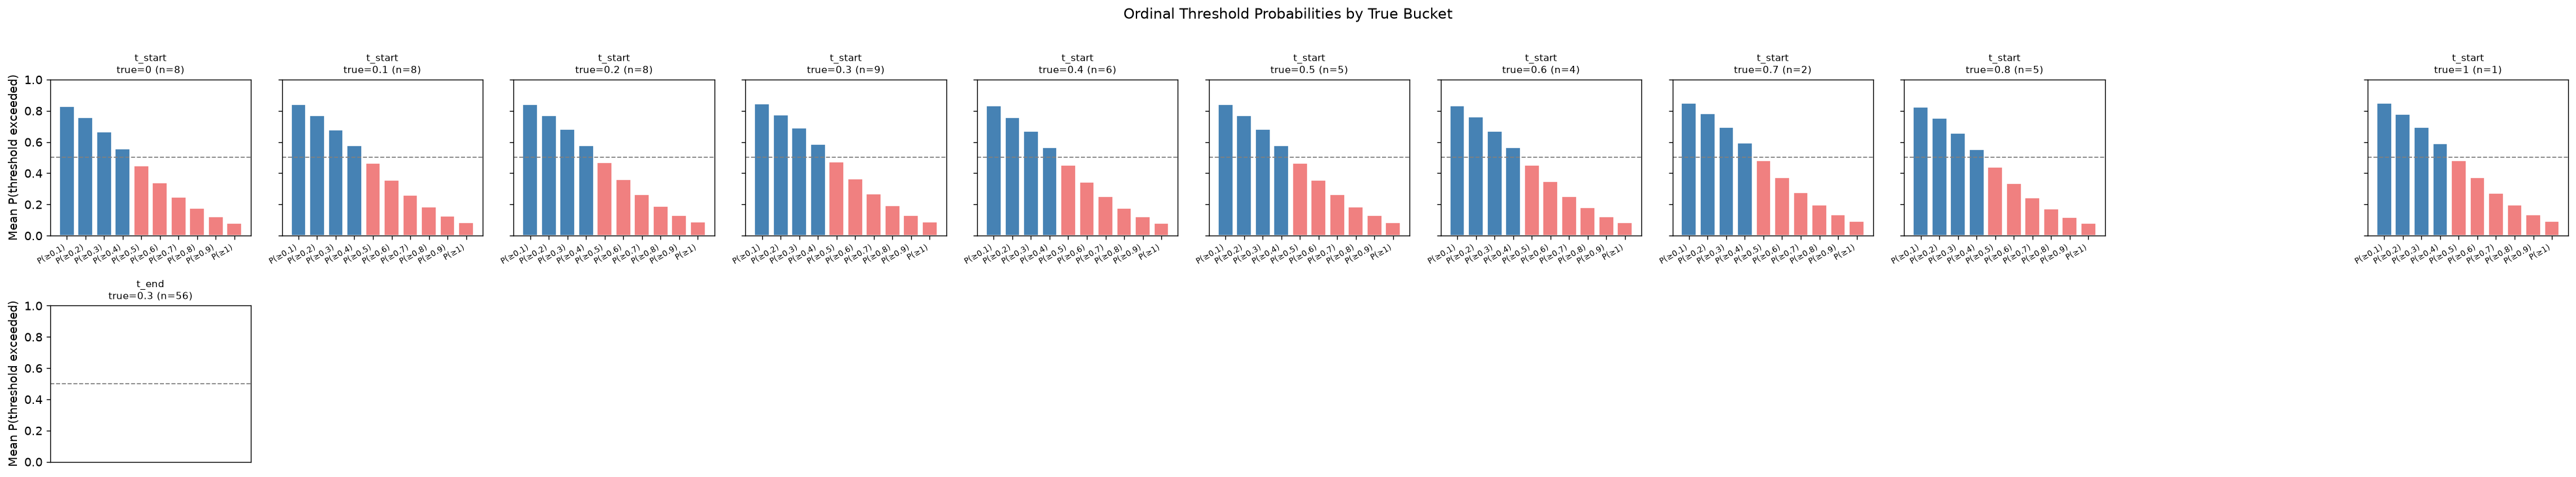

In [12]:
# Show the average sigmoid(logit) per threshold, grouped by true bucket
loader = DataLoader(PairDataset(test_df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

all_logits1, all_logits2, all_l1, all_l2 = [], [], [], []
with torch.no_grad():
    for srcs, tgts, l1, l2 in loader:
        out1, out2 = model(srcs, tgts)
        all_logits1.append(out1.cpu())
        all_logits2.append(out2.cpu())
        all_l1.append(l1)
        all_l2.append(l2)

logits1 = torch.cat(all_logits1).numpy()   # (N, N_BUCKETS_START-1)
logits2 = torch.cat(all_logits2).numpy()   # (N, N_BUCKETS_END-1)
true1   = torch.cat(all_l1).numpy()
true2   = torch.cat(all_l2).numpy()

def sigmoid(x): return 1 / (1 + np.exp(-x))

threshold_labels_start = [f"P(≥{v:.3g})" for v in bucket_vals_start[1:]]
threshold_labels_end   = [f"P(≥{v:.3g})" for v in bucket_vals_end[1:]]

n_cols = max(N_BUCKETS_START, N_BUCKETS_END)
fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 6), sharey=True)

for head_idx, (logits, true, head_name, n_buckets, bucket_labels, thr_labels) in enumerate([
    (logits1, true1, "t_start", N_BUCKETS_START, BUCKET_LABELS_START, threshold_labels_start),
    (logits2, true2, "t_end",   N_BUCKETS_END,   BUCKET_LABELS_END,   threshold_labels_end),
]):
    for bucket in range(n_buckets):
        ax = axes[head_idx][bucket]
        mask = true == bucket
        if mask.sum() == 0:
            ax.set_visible(False)
            continue
        probs = sigmoid(logits[mask]).mean(axis=0)  # (n_buckets-1,)
        colors = ["steelblue" if p > 0.5 else "lightcoral" for p in probs]
        ax.bar(range(n_buckets - 1), probs, color=colors, edgecolor="white")
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.set_xticks(range(n_buckets - 1))
        ax.set_xticklabels(thr_labels, fontsize=7, rotation=30, ha="right")
        ax.set_ylim(0, 1)
        ax.set_title(f"{head_name}\ntrue={bucket_labels[bucket]} (n={mask.sum()})", fontsize=9)
        if bucket == 0:
            ax.set_ylabel("Mean P(threshold exceeded)")
    for bucket in range(n_buckets, n_cols):
        axes[head_idx][bucket].set_visible(False)

plt.suptitle("Ordinal Threshold Probabilities by True Bucket", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/threshold_probs.png", bbox_inches="tight")
plt.show()

## 12. Qualitative Examples

In [13]:
r = results["test"]

test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy["pred_start"] = bucket_vals_start[r["pred_start"]]
test_df_copy["pred_end"]   = bucket_vals_end[r["pred_end"]]
test_df_copy["err_start"]  = abs(r["pred_start"] - r["true_start"])
test_df_copy["err_end"]    = abs(r["pred_end"]   - r["true_end"])
test_df_copy["max_err"]    = test_df_copy[["err_start", "err_end"]].max(axis=1)

# Show: 4 correct predictions and 4 worst mistakes
correct = test_df_copy[(test_df_copy.err_start == 0) & (test_df_copy.err_end == 0)].head(4)
wrong   = test_df_copy.sort_values("max_err", ascending=False).head(4)

def show_examples(df, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    for _, row in df.iterrows():
        print(f"  source: {row['source_prompt'][:80]}")
        print(f"  target: {row['target_prompt'][:80]}")
        print(f"  t_start  true={row['t_start']:.3g}  pred={row['pred_start']:.3g}")
        print(f"  t_end    true={row['t_end']:.3g}  pred={row['pred_end']:.3g}")
        print()

show_examples(correct, "Correct predictions")
show_examples(wrong,   "Largest errors")


  Correct predictions
  source: a [monkey] wearing colorful goggles and a colorful scarf
  target: a [man] wearing colorful goggles and a colorful scarf
  t_start  true=0.4  pred=0.4
  t_end    true=0.3  pred=0.3

  source: a girl with black hair and a white shirt is holding a [phone]
  target: a girl with black hair and a white shirt is holding a [coffee]
  t_start  true=0.4  pred=0.4
  t_end    true=0.3  pred=0.3

  source: a cartoon girl sitting on a [backpack]
  target: a cartoon girl sitting on a [rock]
  t_start  true=0.4  pred=0.4
  t_end    true=0.3  pred=0.3

  source: a large brown teddy bear sitting on a white couch
  target: a large brown teddy bear [and a girl] sitting on a white couch
  t_start  true=0.4  pred=0.4
  t_end    true=0.3  pred=0.3


  Largest errors
  source: winter in lofoten by johan hansen
  target: [digital art of] winter in lofoten by johan hansen
  t_start  true=1  pred=0.4
  t_end    true=0.3  pred=0.3

  source: a blue glass [pendant] on a black cord

## 13. Summary

In [14]:
m = compute_metrics(results["test"])
print("Test-set summary")
print(f"  MAE  t_start: {m['mae_start']:.3f}   t_end: {m['mae_end']:.3f}")
print(f"  Acc  t_start: {m['acc_start']:.1%}  t_end: {m['acc_end']:.1%}")
print(f"  Joint accuracy (both correct): {m['acc_both']:.1%}")
print(f"  Random-chance accuracy: {1/N_BUCKETS_START:.1%} / {1/N_BUCKETS_END:.1%}")

Test-set summary
  MAE  t_start: 2.250   t_end: 0.000
  Acc  t_start: 10.7%  t_end: 100.0%
  Joint accuracy (both correct): 10.7%
  Random-chance accuracy: 9.1% / 100.0%
